**Dataset is Tab separated so we are passing it as a parameter to read it correctly and header is set to none so that our first row might not become the column names**

In [2]:
import pandas as pd
df = pd.read_csv("SMSSpamCollection", sep='\t', header=None)
print("Sucess")


Sucess


**Creating Two Columns Label and Message with ham and spam in label and actual message in message column**

In [3]:
df.columns=["label", "message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Information about our dataset such as spam vs ham (Classification ), NotNull calues  & Datatypes count , shape of dataset**

In [8]:
print(df.shape)
print('Dataset Basic Information is Follow')
df.info()
df['label'].value_counts()


(5572, 2)
Dataset Basic Information is Follow
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


**Class Percentage (Spam vs Not Spam Indicating class Imbalancement)**

In [9]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
ham,86.593683
spam,13.406317


**Class Distribution Bar Chart indicating Class Imbalancement**

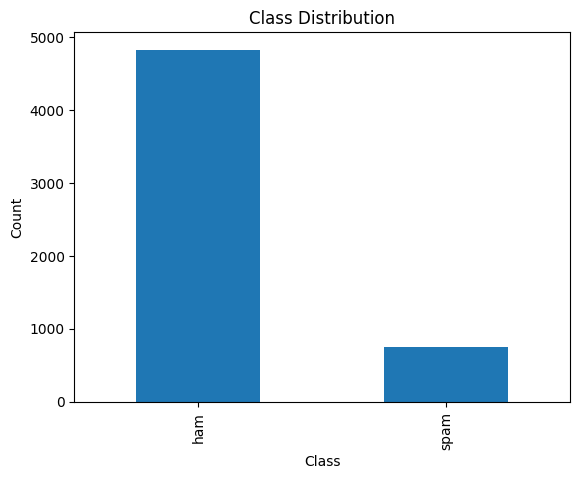

In [17]:
import matplotlib.pyplot as plt

# Count values
counts = df['label'].value_counts()

# Plot
plt.figure()
counts.plot(kind='bar')

# Labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [10]:
df.sample(10)

,label,message
1271,ham,"Sorry chikku, my cell got some problem thts y ..."
4966,ham,"A few people are at the game, I'm at the mall ..."
4327,ham,That seems unnecessarily hostile
3585,spam,Hi 07734396839 IBH Customer Loyalty Offer: The...
4039,ham,Hope you are not scared!
4973,ham,I'm fine. Hope you are good. Do take care.
4956,ham,Doing my masters. When will you buy a bb cos i...
4541,ham,"Urgh, coach hot, smells of chip fat! Thanks ag..."
5425,ham,Otherwise had part time job na-tuition..
3863,ham,"Customer place, i wil cal u sir."


**Creating a Single Text Message bu joining all text and splitting them into words and checking total words in corpus vs unique words**

In [11]:
# Combine all messages into one text
all_text = " ".join(df['message'])

# Split into words
words = all_text.split()

# Total words
total_words = len(words)

# Unique words
unique_words = len(set(words))

total_words, unique_words

(86909, 15691)

**Creating another column indicating total characters in each Message**

In [12]:
# Create a new column for message length
df['message_length'] = df['message'].apply(len)

# Basic statistics
df['message_length'].describe()

,message_length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


In [13]:
print(df['message_length'])

0       111
1        29
2       155
3        49
4        61
       ... 
5567    160
5568     36
5569     57
5570    125
5571     26
Name: message_length, Length: 5572, dtype: int64


****

In [18]:
# Create a copy of original text
df['original_message'] = df['message']

df.head()

,label,message,message_length,original_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...,29,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,49,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
# Convert text to lowercase
df['message'] = df['message'].str.lower()

# Check result
df[['original_message', 'message']].head()

,original_message,message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [20]:
import re

# Remove special characters (keep only alphabets and spaces)
df['message'] = df['message'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

# Check changes
df[['original_message', 'message']].head()

,original_message,message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [21]:
# Split each message into words (tokens)
df['tokens'] = df['message'].apply(lambda x: x.split())

# View result
df[['message', 'tokens']].head()

,message,tokens
0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry in a wkly comp to win fa cup final...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


In [22]:
from nltk.corpus import stopwords
import nltk

# Download stopwords (run only once)
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from tokens
df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# View result
df[['tokens', 'tokens_no_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,tokens_no_stopwords
0,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n..."
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, in, a, wkly, comp, to, win, fa, ...","[free, entry, wkly, comp, win, fa, cup, final,..."
3,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]"
4,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t..."


In [23]:
from nltk.stem import WordNetLemmatizer

# Download required resource (run once)
nltk.download('wordnet')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df['tokens_lemmatized'] = df['tokens_no_stopwords'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

# View results
df[['tokens_no_stopwords', 'tokens_lemmatized']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,tokens_no_stopwords,tokens_lemmatized
0,"[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazy, available, bugis, n..."
1,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,"[free, entry, wkly, comp, win, fa, cup, final,...","[free, entry, wkly, comp, win, fa, cup, final,..."
3,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, early, hor, u, c, already, say]"
4,"[nah, dont, think, goes, usf, lives, around, t...","[nah, dont, think, go, usf, life, around, though]"


In [24]:
# Join tokens back into text
df['final_text'] = df['tokens_lemmatized'].apply(lambda words: " ".join(words))

df[['tokens_lemmatized', 'final_text']].head()

,tokens_lemmatized,final_text
0,"[go, jurong, point, crazy, available, bugis, n...",go jurong point crazy available bugis n great ...
1,"[ok, lar, joking, wif, u, oni]",ok lar joking wif u oni
2,"[free, entry, wkly, comp, win, fa, cup, final,...",free entry wkly comp win fa cup final tkts st ...
3,"[u, dun, say, early, hor, u, c, already, say]",u dun say early hor u c already say
4,"[nah, dont, think, go, usf, life, around, though]",nah dont think go usf life around though


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize BoW
bow = CountVectorizer()

# Fit and transform data
X_bow = bow.fit_transform(df['final_text'])

# Convert to array (for viewing)
X_bow.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [26]:
X_bow.shape

(5572, 7950)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer()

# Fit and transform
X_tfidf = tfidf.fit_transform(df['final_text'])

# Shape
X_tfidf.shape

(5572, 7950)

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigram model
bigram = CountVectorizer(ngram_range=(2,2))

X_bigram = bigram.fit_transform(df['final_text'])

X_bigram.shape

(5572, 30349)

**Assignment 1 + 2 Is completed the remaining is extra work **

In [34]:
# Convert labels to numbers
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

y = df['label_num']

In [35]:
from sklearn.model_selection import train_test_split

# Using TF-IDF features
X = X_tfidf

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.9721973094170404
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [39]:
# Use BoW features
X = X_bow

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.naive_bayes import MultinomialNB

model_bow = MultinomialNB()
model_bow.fit(X_train, y_train)

y_pred_bow = model_bow.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

Accuracy: 0.968609865470852
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       966
           1       0.84      0.95      0.89       149

    accuracy                           0.97      1115
   macro avg       0.91      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [40]:
# Use Bigram features
X = X_bigram

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_bigram = MultinomialNB()
model_bigram.fit(X_train, y_train)

y_pred_bigram = model_bigram.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bigram))
print(classification_report(y_test, y_pred_bigram))

Accuracy: 0.7677130044843049
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       966
           1       0.36      0.99      0.53       149

    accuracy                           0.77      1115
   macro avg       0.68      0.86      0.69      1115
weighted avg       0.91      0.77      0.80      1115



In [41]:
def predict_message(text):
    # Step 1: lowercase
    text = text.lower()

    # Step 2: remove special characters
    import re
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: tokenize
    words = text.split()

    # Step 4: remove stopwords
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Step 5: lemmatization
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # Step 6: join back
    final = " ".join(words)

    # Step 7: convert using SAME TF-IDF
    vector = tfidf.transform([final])

    # Step 8: predict
    prediction = model.predict(vector)[0]

    return "Spam" if prediction == 1 else "Ham"

In [52]:
predict_message("Call me at 03001234567 when you're free, got something important to tell you.")

'Ham'